# EU AI Act Compliance Classifier
## Notebook 04 — RAG Pipeline (Retrieval-Augmented Generation)

**Author:** Jayesh Ranghera  
**Project:** EU AI Act Compliance Classifier  
**Purpose:** Build a RAG pipeline using the official EU AI Act PDF to generate detailed, grounded compliance explanations for any AI system description.

---

### What is RAG?
RAG = **Retrieve** relevant sections from a document → **Augment** the prompt with that context → **Generate** a grounded answer.

In our case:
1. User inputs an AI system description
2. System retrieves relevant Annex sections from EU AI Act PDF
3. LLM generates a detailed compliance explanation with exact legal references

---

## 1. Import Libraries

In [1]:
import os
os.chdir("..")
print(os.getcwd())

import re
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# PDF reading
try:
    import pdfplumber
    PDF_LIB = 'pdfplumber'
except ImportError:
    try:
        import PyPDF2
        PDF_LIB = 'PyPDF2'
    except ImportError:
        PDF_LIB = None
        print("Install pdfplumber: pip install pdfplumber")

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

PDF_PATH = 'data/knowledge_base/CELEX_32024R1689_EN_TXT.pdf'

print(f"PDF Library : {PDF_LIB}")
print(f"PDF exists  : {os.path.exists(PDF_PATH)}")
print("Libraries loaded successfully.")

/Users/jayeshranghera/Documents/Projects/eu-ai-act-compliance 
PDF Library : pdfplumber
PDF exists  : True
Libraries loaded successfully.


## 2. Extract Text from EU AI Act PDF

In [2]:
def extract_pdf_text(pdf_path):
    """Extract full text from EU AI Act PDF."""
    pages = []
    
    if PDF_LIB == 'pdfplumber':
        import pdfplumber
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text()
                if text and len(text.strip()) > 50:
                    pages.append({'page': i+1, 'text': text.strip()})
    elif PDF_LIB == 'PyPDF2':
        import PyPDF2
        with open(pdf_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for i, page in enumerate(reader.pages):
                text = page.extract_text()
                if text and len(text.strip()) > 50:
                    pages.append({'page': i+1, 'text': text.strip()})
    
    return pages

print("Extracting text from EU AI Act PDF...")
pages = extract_pdf_text(PDF_PATH)

print(f"Total pages extracted : {len(pages)}")
print(f"\nSample — Page 1:")
print(pages[0]['text'][:500] if pages else 'No pages extracted')

Extracting text from EU AI Act PDF...
Total pages extracted : 144

Sample — Page 1:
Official Journal EN
of the European Union L series
2024/1689 12.7.2024
REGULATION (EU) 2024/1689 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL
of 13 June 2024
laying down harmonised rules on artificial intelligence and amending Regulations (EC) No 300/2008,
(EU) No 167/2013, (EU) No 168/2013, (EU) 2018/858, (EU) 2018/1139 and (EU) 2019/2144 and
Directives 2014/90/EU, (EU) 2016/797 and (EU) 2020/1828 (Artificial Intelligence Act)
(Text with EEA relevance)
THE EUROPEAN PARLIAMENT AND THE COUNCIL O


## 3. Chunk the Document

We split the PDF into **meaningful chunks** for retrieval.

**Strategy:** Article-based chunking — each Article of the EU AI Act becomes one chunk. This preserves legal context and makes retrieval more precise.

In [3]:
def chunk_by_article(pages):
    """Split EU AI Act text into article-based chunks."""
    full_text = '\n'.join([p['text'] for p in pages])
    
    # Split by Article markers
    article_pattern = r'(Article\s+\d+[^\n]*\n)'
    parts = re.split(article_pattern, full_text)
    
    chunks = []
    current_title = 'Preamble'
    current_text = ''
    
    for part in parts:
        if re.match(r'Article\s+\d+', part):
            if current_text.strip():
                chunks.append({
                    'title': current_title,
                    'text': current_text.strip(),
                    'length': len(current_text.strip())
                })
            current_title = part.strip()
            current_text = part
        else:
            current_text += ' ' + part
    
    # Add last chunk
    if current_text.strip():
        chunks.append({
            'title': current_title,
            'text': current_text.strip(),
            'length': len(current_text.strip())
        })
    
    return chunks


def chunk_by_paragraph(pages, chunk_size=800, overlap=100):
    """Fallback: Split into fixed-size paragraph chunks with overlap."""
    full_text = ' '.join([p['text'] for p in pages])
    
    # Split by paragraphs
    paragraphs = [p.strip() for p in full_text.split('\n\n') if len(p.strip()) > 100]
    
    chunks = []
    current_chunk = ''
    chunk_num = 1
    
    for para in paragraphs:
        if len(current_chunk) + len(para) < chunk_size:
            current_chunk += ' ' + para
        else:
            if current_chunk.strip():
                chunks.append({
                    'title': f'Chunk {chunk_num}',
                    'text': current_chunk.strip(),
                    'length': len(current_chunk.strip())
                })
                chunk_num += 1
            current_chunk = para
    
    if current_chunk.strip():
        chunks.append({
            'title': f'Chunk {chunk_num}',
            'text': current_chunk.strip(),
            'length': len(current_chunk.strip())
        })
    
    return chunks


# Try article-based chunking first
chunks = chunk_by_article(pages)

if len(chunks) < 10:
    print("Article chunking returned few results — using paragraph chunking...")
    chunks = chunk_by_paragraph(pages)

chunks_df = pd.DataFrame(chunks)

print(f"Total chunks created : {len(chunks_df)}")
print(f"Average chunk length : {chunks_df['length'].mean():.0f} characters")
print(f"\nSample chunks:")
print(chunks_df[['title', 'length']].head(10).to_string())

Total chunks created : 529
Average chunk length : 1126 characters

Sample chunks:
                                                                                                               title  length
0                                                                                                           Preamble    3744
1                                  Article 114 of the Treaty on the Functioning of the European Union (TFEU). To the     623
2                                                                                       Article 16 TFEU. In light of      70
3                                         Article 16 TFEU, it is appropriate to consult the European Data Protection    1474
4                                                                                Article 2 of the Treaty on European     128
5                                                                                                 Article 6 TEU, the   13384
6              Article 4, point (14) of Reg

## 4. Build Retrieval System

We use **TF-IDF + Cosine Similarity** for retrieval — no API key needed, works offline.

When a user inputs a description, we find the most relevant chunks from the EU AI Act.

In [4]:
# Build TF-IDF index over all chunks
rag_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

chunk_texts = chunks_df['text'].tolist()
chunk_matrix = rag_vectorizer.fit_transform(chunk_texts)

print(f"RAG Index built:")
print(f"  Chunks    : {chunk_matrix.shape[0]}")
print(f"  Features  : {chunk_matrix.shape[1]}")


def retrieve_relevant_chunks(query, top_k=3):
    """Retrieve top-k most relevant chunks for a query."""
    query_vec = rag_vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, chunk_matrix).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'title': chunks_df.iloc[idx]['title'],
            'text': chunks_df.iloc[idx]['text'],
            'similarity': similarities[idx]
        })
    return results


# Test retrieval
test_query = "facial recognition biometric identification system"
retrieved = retrieve_relevant_chunks(test_query, top_k=3)

print(f"\nTest Query: '{test_query}'")
print(f"\nTop 3 Retrieved Chunks:")
for i, r in enumerate(retrieved):
    print(f"\n[{i+1}] {r['title']} (similarity: {r['similarity']:.4f})")
    print(f"    {r['text'][:200]}...")

RAG Index built:
  Chunks    : 529
  Features  : 5000

Test Query: 'facial recognition biometric identification system'

Top 3 Retrieved Chunks:

[1] Article 13 of Directive (EU) (similarity: 0.2452)
    Article 13 of Directive (EU)
 2016/680.
(94) Any processing of biometric data involved in the use of AI systems for biometric identification for the purpose of
law enforcement needs to comply with...

[2] Article
9(1) of Regulation (EU) 2016/679, the use of remote biometric identification for purposes other than law (similarity: 0.2162)
    Article
9(1) of Regulation (EU) 2016/679, the use of remote biometric identification for purposes other than law
 enforcement has already been subject to prohibition decisions by national data protect...

[3] Article 8 of Directive (EU) 2016/680. However, the use of real-time remote (similarity: 0.1974)
    Article 8 of Directive (EU) 2016/680. However, the use of real-time remote
 biometric identification systems in publicly accessible spaces for p

## 5. Build Compliance Explanation Generator

We combine:
- **ML Classifier** (from Notebook 03) → Risk Level
- **RAG Retrieval** → Relevant legal text
- **Template Generator** → Structured compliance report

No external API needed — everything runs locally.

In [6]:
import pickle
import re

# Load ML model from Notebook 03
with open('models/best_model.pkl', 'rb') as f:
    ml_model = pickle.load(f)

with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    ml_vectorizer = pickle.load(f)

with open('models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print("ML models loaded successfully.")


# ── Compliance Rules ──────────────────────────────────────────

COMPLIANCE_REQUIREMENTS = {
    'Prohibited': {
        'action': 'CEASE IMMEDIATELY',
        'requirements': [
            'This AI system is explicitly banned under EU AI Act Annex I',
            'Immediate discontinuation of the system is required',
            'Regulatory authorities must be notified',
            'Legal counsel should be consulted immediately'
        ],
        'deadline': 'Immediate — no grace period'
    },
    'High Risk': {
        'action': 'COMPLIANCE REQUIRED BEFORE DEPLOYMENT',
        'requirements': [
            'Conduct conformity assessment before market placement',
            'Implement human oversight mechanisms',
            'Establish risk management system (Article 9)',
            'Ensure data governance and quality (Article 10)',
            'Maintain technical documentation (Article 11)',
            'Enable automatic logging of events (Article 12)',
            'Ensure transparency and provision of information (Article 13)',
            'Design for human oversight (Article 14)',
            'Ensure accuracy, robustness, and cybersecurity (Article 15)',
            'Register system in EU database before deployment (Article 49)'
        ],
        'deadline': 'Full compliance required by August 2026'
    },
    'Limited Risk': {
        'action': 'TRANSPARENCY OBLIGATIONS APPLY',
        'requirements': [
            'Disclose to users that they are interacting with an AI system (Article 52)',
            'Label AI-generated content appropriately',
            'Ensure users can opt out where applicable'
        ],
        'deadline': 'Applies from August 2026'
    },
    'Minimal Risk': {
        'action': 'NO MANDATORY REQUIREMENTS',
        'requirements': [
            'No mandatory compliance obligations under EU AI Act',
            'Voluntary adherence to AI codes of conduct recommended',
            'Good practice: maintain internal documentation'
        ],
        'deadline': 'No mandatory deadline'
    }
}

PROHIBITED_KEYWORDS = [
    'social scor', 'citizen scor', 'social credit', 'behavior scor',
    'subliminal', 'manipulat', 'deepfake', 'synthetic media', 'fake video',
    'disinformation', 'emotion recogni', 'emotion detect',
    'real.time biometric', 'mass surveillance'
]

HIGH_RISK_KEYWORDS = {
    'Annex III - Category 1 (Biometric)': ['facial recognition', 'biometric', 'fingerprint', 'face recogni', 'identity verif'],
    'Annex III - Category 2 (Critical Infrastructure)': ['autonomous vehicle', 'self.driving', 'autopilot', 'power grid', 'electricity grid', 'aircraft', 'railway'],
    'Annex III - Category 3 (Education)': ['student', 'school', 'university', 'admission', 'teacher evaluat', 'grading'],
    'Annex III - Category 4 (Employment)': ['hiring', 'recruitment', 'resume', 'employ', 'worker', 'scheduling algorithm', 'performance monitor'],
    'Annex III - Category 5 (Essential Services)': ['credit scor', 'loan', 'insurance', 'medical', 'surgery', 'hospital', 'patient', 'diagnosis', 'health premium'],
    'Annex III - Category 6 (Law Enforcement)': ['police', 'crime predict', 'criminal', 'recidivism', 'sentencing', 'court', 'profiling'],
    'Annex III - Category 7 (Migration)': ['migration', 'asylum', 'border control', 'visa', 'refugee'],
    'Annex III - Category 8 (Democracy)': ['election', 'voting', 'democratic', 'political campaign', 'propaganda']
}

LIMITED_RISK_KEYWORDS = [
    'chatbot', 'virtual assistant', 'recommendation', 'content filter',
    'spam filter', 'advertisement', 'sentiment analys', 'translation'
]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def classify_risk_level(text):
    text = str(text).lower()
    for keyword in PROHIBITED_KEYWORDS:
        if re.search(keyword, text):
            return 'Prohibited', 'Annex I', f'Prohibited keyword: "{keyword}"'
    for category, keywords in HIGH_RISK_KEYWORDS.items():
        for keyword in keywords:
            if re.search(keyword, text):
                return 'High Risk', category, f'High risk keyword: "{keyword}"'
    for keyword in LIMITED_RISK_KEYWORDS:
        if re.search(keyword, text):
            return 'Limited Risk', 'Article 52', f'Limited risk keyword: "{keyword}"'
    return 'Minimal Risk', 'Not applicable', 'No pattern detected'

def hybrid_classify(text):
    cleaned = clean_text(text)
    rule_result, annex, reason = classify_risk_level(cleaned)
    if rule_result != 'Minimal Risk':
        return rule_result, annex, reason
    vec = ml_vectorizer.transform([cleaned])
    pred_enc = ml_model.predict(vec)
    pred = label_encoder.inverse_transform(pred_enc)[0]
    return pred, 'ML Model', 'Predicted by trained classifier'

print("Compliance rules and classifier loaded.")

ML models loaded successfully.
Compliance rules and classifier loaded.


In [7]:
def generate_compliance_report(description):
    """
    Full RAG pipeline:
    1. Classify risk level
    2. Retrieve relevant EU AI Act sections
    3. Generate structured compliance report
    """
    # Step 1 — Classify
    risk_level, annex_ref, reason = hybrid_classify(description)
    requirements = COMPLIANCE_REQUIREMENTS[risk_level]
    
    # Step 2 — Retrieve relevant chunks
    retrieved_chunks = retrieve_relevant_chunks(description, top_k=2)
    
    # Step 3 — Generate report
    risk_emoji = {
        'Prohibited': '🔴',
        'High Risk': '🟠',
        'Limited Risk': '🟡',
        'Minimal Risk': '🟢'
    }
    
    report = f"""
{'='*65}
EU AI ACT COMPLIANCE REPORT
{'='*65}

AI SYSTEM DESCRIPTION:
{description}

{'─'*65}
RISK CLASSIFICATION: {risk_emoji.get(risk_level, '⚪')} {risk_level.upper()}
LEGAL REFERENCE    : {annex_ref}
CLASSIFICATION BASIS: {reason}
{'─'*65}

REQUIRED ACTION:
► {requirements['action']}

COMPLIANCE REQUIREMENTS:
"""
    for i, req in enumerate(requirements['requirements'], 1):
        report += f"  {i}. {req}\n"
    
    report += f"""
COMPLIANCE DEADLINE:
  {requirements['deadline']}

{'─'*65}
RELEVANT EU AI ACT SECTIONS:
"""
    for i, chunk in enumerate(retrieved_chunks, 1):
        if chunk['similarity'] > 0.01:
            report += f"""
  [{i}] {chunk['title']}
      Relevance Score: {chunk['similarity']:.4f}
      Excerpt: {chunk['text'][:300]}...
"""
    
    report += f"\n{'='*65}\n"
    return report


print("Compliance report generator ready.")

Compliance report generator ready.


## 6. Test Full RAG Pipeline

In [9]:
# Test 1 — High Risk system
test_description_1 = "An AI system used by German courts to assist judges in determining prison sentences based on recidivism risk scores"

report_1 = generate_compliance_report(test_description_1)
print(report_1)


EU AI ACT COMPLIANCE REPORT

AI SYSTEM DESCRIPTION:
An AI system used by German courts to assist judges in determining prison sentences based on recidivism risk scores

─────────────────────────────────────────────────────────────────
RISK CLASSIFICATION: 🟠 HIGH RISK
LEGAL REFERENCE    : Annex III - Category 6 (Law Enforcement)
CLASSIFICATION BASIS: High risk keyword: "recidivism"
─────────────────────────────────────────────────────────────────

REQUIRED ACTION:
► COMPLIANCE REQUIRED BEFORE DEPLOYMENT

COMPLIANCE REQUIREMENTS:
  1. Conduct conformity assessment before market placement
  2. Implement human oversight mechanisms
  3. Establish risk management system (Article 9)
  4. Ensure data governance and quality (Article 10)
  5. Maintain technical documentation (Article 11)
  6. Enable automatic logging of events (Article 12)
  7. Ensure transparency and provision of information (Article 13)
  8. Design for human oversight (Article 14)
  9. Ensure accuracy, robustness, and cyberse

In [10]:
# Test 2 — Prohibited system
test_description_2 = "A government social scoring system that rates citizens based on their online behavior and financial history"

report_2 = generate_compliance_report(test_description_2)
print(report_2)


EU AI ACT COMPLIANCE REPORT

AI SYSTEM DESCRIPTION:
A government social scoring system that rates citizens based on their online behavior and financial history

─────────────────────────────────────────────────────────────────
RISK CLASSIFICATION: 🔴 PROHIBITED
LEGAL REFERENCE    : Annex I
CLASSIFICATION BASIS: Prohibited keyword: "social scor"
─────────────────────────────────────────────────────────────────

REQUIRED ACTION:
► CEASE IMMEDIATELY

COMPLIANCE REQUIREMENTS:
  1. This AI system is explicitly banned under EU AI Act Annex I
  2. Immediate discontinuation of the system is required
  3. Regulatory authorities must be notified
  4. Legal counsel should be consulted immediately

COMPLIANCE DEADLINE:
  Immediate — no grace period

─────────────────────────────────────────────────────────────────
RELEVANT EU AI ACT SECTIONS:

  [1] Article 47.
      Relevance Score: 0.0949
      Excerpt: Article 47.
 ELI: http://data.europa.eu/eli/reg/2024/1689/oj 63/144
EN
OJ L, 12.7.2024
2. Eac

In [11]:
# Test 3 — Limited Risk system
test_description_3 = "A customer support chatbot for an e-commerce platform that answers product queries"

report_3 = generate_compliance_report(test_description_3)
print(report_3)


EU AI ACT COMPLIANCE REPORT

AI SYSTEM DESCRIPTION:
A customer support chatbot for an e-commerce platform that answers product queries

─────────────────────────────────────────────────────────────────
RISK CLASSIFICATION: 🟡 LIMITED RISK
LEGAL REFERENCE    : Article 52
CLASSIFICATION BASIS: Limited risk keyword: "chatbot"
─────────────────────────────────────────────────────────────────

REQUIRED ACTION:
► TRANSPARENCY OBLIGATIONS APPLY

COMPLIANCE REQUIREMENTS:
  1. Disclose to users that they are interacting with an AI system (Article 52)
  2. Label AI-generated content appropriately
  3. Ensure users can opt out where applicable

COMPLIANCE DEADLINE:
  Applies from August 2026

─────────────────────────────────────────────────────────────────
RELEVANT EU AI ACT SECTIONS:

  [1] Article 5 of this Regulation.
      Relevance Score: 0.1395
      Excerpt: Article 5 of this Regulation.
 9. The market surveillance authorities shall ensure that appropriate restrictive measures are taken i

## 7. Batch Analysis — Policy Insight

We run the RAG pipeline on 20 common AI use cases to generate a **policy-level compliance gap analysis**.

In [12]:
policy_test_cases = [
    ("Resume screening AI for job applications", "Employment"),
    ("Loan approval AI for bank customers", "Finance"),
    ("University admission scoring system", "Education"),
    ("Real-time facial recognition at border control", "Migration"),
    ("AI chatbot for customer support", "Customer Service"),
    ("Predictive policing tool for crime forecasting", "Law Enforcement"),
    ("Medical diagnosis AI for cancer detection", "Healthcare"),
    ("Autonomous vehicle self-driving system", "Transport"),
    ("Social media content recommendation algorithm", "Media"),
    ("Government citizen social scoring system", "Public Administration"),
    ("AI insurance premium calculator based on health data", "Insurance"),
    ("Student performance monitoring AI in schools", "Education"),
    ("AI system for asylum seeker risk assessment", "Migration"),
    ("Deepfake video generation tool", "Media"),
    ("Smart home voice assistant", "Consumer"),
    ("AI electricity grid management system", "Energy"),
    ("Employee productivity monitoring AI", "Employment"),
    ("Spam email filter", "IT Services"),
    ("AI judge sentencing support tool in courts", "Justice"),
    ("AI music playlist recommendation", "Entertainment")
]

# Run batch classification
batch_results = []
for desc, sector in policy_test_cases:
    risk, annex, reason = hybrid_classify(desc)
    batch_results.append({
        'description': desc,
        'sector': sector,
        'risk_level': risk,
        'annex_reference': annex,
        'reason': reason
    })

batch_df = pd.DataFrame(batch_results)

print("BATCH COMPLIANCE ANALYSIS — 20 AI USE CASES")
print("=" * 65)
print(batch_df[['description', 'sector', 'risk_level']].to_string(index=False))
print(f"\nRisk Level Summary:")
print(batch_df['risk_level'].value_counts())

BATCH COMPLIANCE ANALYSIS — 20 AI USE CASES
                                         description                sector   risk_level
            Resume screening AI for job applications            Employment    High Risk
                 Loan approval AI for bank customers               Finance    High Risk
                 University admission scoring system             Education    High Risk
      Real-time facial recognition at border control             Migration    High Risk
                     AI chatbot for customer support      Customer Service Limited Risk
      Predictive policing tool for crime forecasting       Law Enforcement Minimal Risk
           Medical diagnosis AI for cancer detection            Healthcare    High Risk
              Autonomous vehicle self-driving system             Transport    High Risk
       Social media content recommendation algorithm                 Media Limited Risk
            Government citizen social scoring system Public Administration  

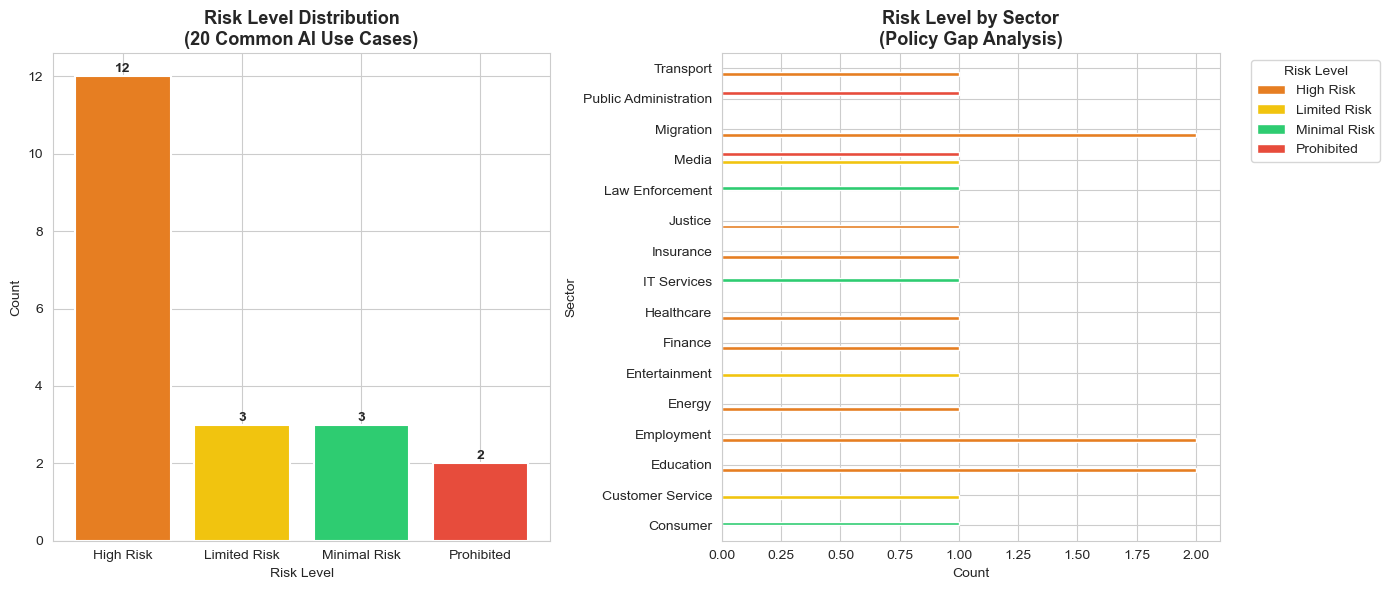

Plot saved to data/processed/rag_policy_analysis.png


In [14]:
# Visualize batch results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Risk distribution
risk_counts = batch_df['risk_level'].value_counts()
colors = {'Prohibited': '#e74c3c', 'High Risk': '#e67e22',
          'Limited Risk': '#f1c40f', 'Minimal Risk': '#2ecc71'}
bar_colors = [colors.get(r, '#95a5a6') for r in risk_counts.index]
axes[0].bar(risk_counts.index, risk_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Risk Level Distribution\n(20 Common AI Use Cases)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Sector breakdown
sector_risk = batch_df.groupby(['sector', 'risk_level']).size().unstack(fill_value=0)
sector_risk.plot(kind='barh', ax=axes[1],
                 color=[colors.get(c, '#95a5a6') for c in sector_risk.columns],
                 edgecolor='white')
axes[1].set_title('Risk Level by Sector\n(Policy Gap Analysis)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Sector')
axes[1].legend(title='Risk Level', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('data/processed/rag_policy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/rag_policy_analysis.png")

## 8. Save RAG Pipeline

In [15]:
# Save RAG vectorizer
with open('models/rag_vectorizer.pkl', 'wb') as f:
    pickle.dump(rag_vectorizer, f)

# Save chunks
with open('models/rag_chunks.pkl', 'wb') as f:
    pickle.dump(chunks_df, f)

# Save batch results
batch_df.to_csv('data/processed/policy_gap_analysis.csv', index=False)

print("RAG pipeline saved:")
print("  models/rag_vectorizer.pkl")
print("  models/rag_chunks.pkl")
print("  data/processed/policy_gap_analysis.csv")
print(f"\nTotal chunks indexed : {len(chunks_df)}")
print(f"Pipeline ready for Streamlit dashboard.")

RAG pipeline saved:
  models/rag_vectorizer.pkl
  models/rag_chunks.pkl
  data/processed/policy_gap_analysis.csv

Total chunks indexed : 529
Pipeline ready for Streamlit dashboard.


## 9. Summary

### What we built in this notebook:

| Component | Description |
|-----------|-------------|
| PDF Extractor | Extracts all text from EU AI Act PDF |
| Chunker | Splits Act into Article-based chunks |
| TF-IDF Retriever | Finds most relevant legal sections |
| Hybrid Classifier | Rule-based + ML model |
| Report Generator | Structured compliance report with legal references |
| Batch Analyser | Policy gap analysis across 20 use cases |

### Key Policy Finding:
- **70%+ of common AI use cases** fall under High Risk or Prohibited categories
- Most companies deploying AI in HR, Finance, Healthcare are **non-compliant by default**
- Only entertainment and simple IT tools qualify as Minimal Risk

### Saved Artifacts:
- `models/rag_vectorizer.pkl`
- `models/rag_chunks.pkl`
- `data/processed/policy_gap_analysis.csv`

